# POST-PROCESS ANALYSIS 

## CODE SEQUENCE 3
### INPUT: STEP 2 CODE
### OUTPUT: STATISTICAL RESULTS 
This code does a statistical analysis on the collected data.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare, wilcoxon, binomtest
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import confusion_matrix

# ============================================================
# PATH
# ============================================================

base_path = Path(r"C:\Users\a.genua\OneDrive - Scuola Superiore Sant'Anna\PROGETTI\Progetti in corso\Articoli in corso\RA-L_&_Sanseverino\FlightSimulator")

input_csv = base_path / "2back_responses_only_final.csv"

df_wide = pd.read_csv(input_csv)

print("Shape CSV:", df_wide.shape)
print(df_wide.columns.tolist()[:10])
df_wide.head()

Shape CSV: (484, 180)
['ID1_NOMINAL_expected_response', 'ID1_NOMINAL_subject_response', 'ID1_LOW_expected_response', 'ID1_LOW_subject_response', 'ID1_HIGH_expected_response', 'ID1_HIGH_subject_response', 'ID2_NOMINAL_expected_response', 'ID2_NOMINAL_subject_response', 'ID2_LOW_expected_response', 'ID2_LOW_subject_response']


,ID1_NOMINAL_expected_response,ID1_NOMINAL_subject_response,ID1_LOW_expected_response,ID1_LOW_subject_response,ID1_HIGH_expected_response,ID1_HIGH_subject_response,ID2_NOMINAL_expected_response,ID2_NOMINAL_subject_response,ID2_LOW_expected_response,ID2_LOW_subject_response,...,ID29_LOW_expected_response,ID29_LOW_subject_response,ID29_HIGH_expected_response,ID29_HIGH_subject_response,ID30_NOMINAL_expected_response,ID30_NOMINAL_subject_response,ID30_LOW_expected_response,ID30_LOW_subject_response,ID30_HIGH_expected_response,ID30_HIGH_subject_response
0,Red,Red,Blue,Blue,Red,Red,Green,Green,Yellow,Yellow,...,Blue,Blue,Red,Blue,Green,Green,Green,Green,Yellow,Yellow
1,Red,Red,Yellow,Yellow,Red,Green,Red,Green,Blue,Blue,...,Yellow,Yellow,Blue,Blue,Red,Red,Yellow,Yellow,Red,Red
2,Yellow,Yellow,Red,Red,Red,Red,Blue,Blue,Yellow,Yellow,...,Yellow,Yellow,Green,Green,Blue,Blue,Red,Red,Green,Green
3,Red,Red,Red,Red,Green,Green,Red,Red,Yellow,Yellow,...,Green,Green,Blue,Blue,Green,Green,Green,Green,Green,Green
4,Green,Green,Red,Blue,Green,Green,Red,Red,Blue,Blue,...,Yellow,Yellow,Green,Green,Green,Green,Blue,Blue,Green,Green


## TRASFORMAZIONE DA WIDE A LONG

In questo step il file csv è convertito in una tabella lunga con colonne.

In [2]:
# ============================================================
# WIDE -> LONG
# ============================================================

pattern = re.compile(r"^(ID\d+)_(NOMINAL|LOW|HIGH)_(expected_response|subject_response)$")

parsed_cols = []
for col in df_wide.columns:
    m = pattern.match(col)
    if m:
        parsed_cols.append({
            "column": col,
            "subject": m.group(1),
            "condition": m.group(2),
            "kind": m.group(3),
        })

meta_df = pd.DataFrame(parsed_cols)

records = []

for (subject, condition), group in meta_df.groupby(["subject", "condition"]):
    exp_col = group.loc[group["kind"] == "expected_response", "column"]
    sub_col = group.loc[group["kind"] == "subject_response", "column"]

    if len(exp_col) == 0 or len(sub_col) == 0:
        continue

    exp_col = exp_col.iloc[0]
    sub_col = sub_col.iloc[0]

    temp = pd.DataFrame({
        "subject": subject,
        "condition": condition,
        "trial_index": np.arange(1, len(df_wide) + 1),
        "expected_response": df_wide[exp_col],
        "subject_response": df_wide[sub_col],
    })

    records.append(temp)

df_long = pd.concat(records, ignore_index=True)

print("Shape long grezzo:", df_long.shape)
df_long.head()

Shape long grezzo: (43560, 5)


,subject,condition,trial_index,expected_response,subject_response
0,ID1,HIGH,1,Red,Red
1,ID1,HIGH,2,Red,Green
2,ID1,HIGH,3,Red,Red
3,ID1,HIGH,4,Green,Green
4,ID1,HIGH,5,Green,Green


## SELEZIONE DEI TRIAL CON RISPOSTA CORRETTA

Qui vengono filtrate solo le risposte esatte


In [3]:
# ============================================================
# PULIZIA
# ============================================================

df_long["expected_response"] = df_long["expected_response"].fillna("").astype(str).str.strip()
df_long["subject_response"] = df_long["subject_response"].fillna("").astype(str).str.strip()

# solo trial validi del 2-back
df_valid = df_long[df_long["expected_response"] != ""].copy()

# risposta mancante = omissione
df_valid["response_missing"] = df_valid["subject_response"] == ""

# correttezza
df_valid["is_correct"] = df_valid["expected_response"] == df_valid["subject_response"]

print("Shape valid:", df_valid.shape)
print(df_valid.head())

Shape valid: (2404, 7)
  subject condition  trial_index expected_response subject_response  \
0     ID1      HIGH            1               Red              Red   
1     ID1      HIGH            2               Red            Green   
2     ID1      HIGH            3               Red              Red   
3     ID1      HIGH            4             Green            Green   
4     ID1      HIGH            5             Green            Green   

   response_missing  is_correct  
0             False        True  
1             False       False  
2             False        True  
3             False        True  
4             False        True  


## METRICHE BASE

Studio delle metriche di base


In [4]:
# ============================================================
# METRICHE BASE
# ============================================================

summary_sc = (
    df_valid.groupby(["subject", "condition"])
    .agg(
        n_trials=("is_correct", "size"),
        accuracy=("is_correct", "mean"),
        omission_rate=("response_missing", "mean"),
    )
    .reset_index()
)

print(summary_sc)

   subject condition  n_trials  accuracy  omission_rate
0      ID1      HIGH        26  0.653846       0.000000
1      ID1       LOW        26  0.846154       0.000000
2      ID1   NOMINAL        27  0.962963       0.000000
3     ID10      HIGH        26  0.653846       0.000000
4     ID10       LOW        28  0.535714       0.035714
..     ...       ...       ...       ...            ...
85     ID8       LOW        24  0.416667       0.083333
86     ID8   NOMINAL        19  0.842105       0.000000
87     ID9      HIGH        29  0.586207       0.000000
88     ID9       LOW        23  0.826087       0.000000
89     ID9   NOMINAL        31  0.419355       0.064516

[90 rows x 5 columns]


In [5]:
summary_cond = (
    df_valid.groupby("condition")
    .agg(
        n_trials=("is_correct", "size"),
        accuracy_mean=("is_correct", "mean"),
        accuracy_std=("is_correct", "std"),
        omission_mean=("response_missing", "mean"),
        omission_std=("response_missing", "std"),
    )
    .reset_index()
)

print(summary_cond)

  condition  n_trials  accuracy_mean  accuracy_std  omission_mean  \
0      HIGH       811       0.836005      0.370500       0.024661   
1       LOW       802       0.748130      0.434358       0.031172   
2   NOMINAL       791       0.876106      0.329669       0.011378   

   omission_std  
0      0.155185  
1      0.173891  
2      0.106126  


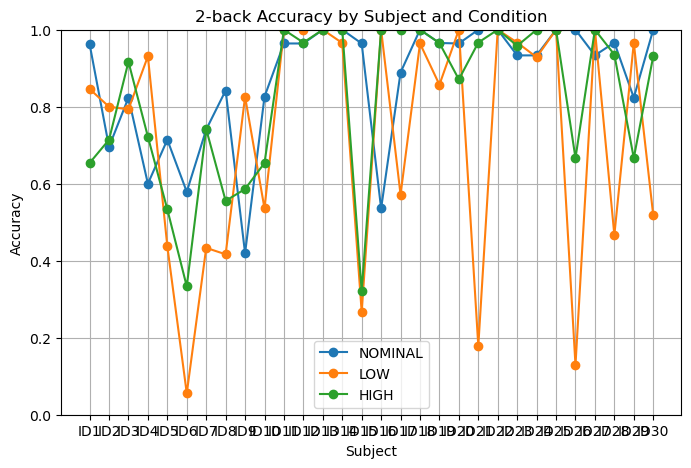

In [6]:
acc_plot = summary_sc.pivot(index="subject", columns="condition", values="accuracy")

acc_plot = acc_plot.reindex(sorted(acc_plot.index, key=lambda x: int(x.replace("ID", ""))))

plt.figure(figsize=(8, 5))
for cond in ["NOMINAL", "LOW", "HIGH"]:
    if cond in acc_plot.columns:
        plt.plot(acc_plot.index, acc_plot[cond], marker="o", label=cond)

plt.ylabel("Accuracy")
plt.xlabel("Subject")
plt.title("2-back Accuracy by Subject and Condition")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

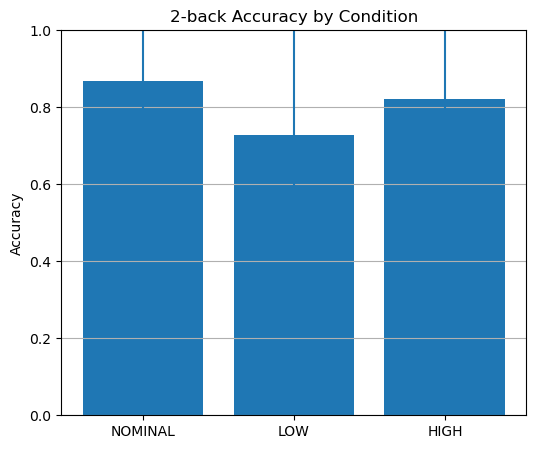

In [7]:
stats_cond = summary_sc.groupby("condition")["accuracy"].agg(["mean", "std"]).reindex(["NOMINAL", "LOW", "HIGH"])

plt.figure(figsize=(6, 5))
plt.bar(stats_cond.index, stats_cond["mean"])
plt.errorbar(stats_cond.index, stats_cond["mean"], yerr=stats_cond["std"], fmt="none", capsize=5)

plt.ylabel("Accuracy")
plt.title("2-back Accuracy by Condition")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

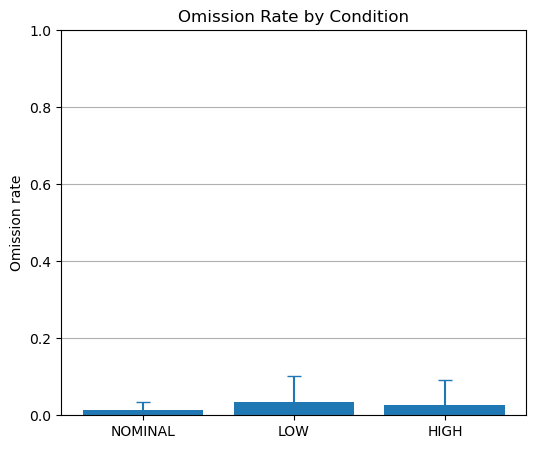

In [8]:
omit_cond = summary_sc.groupby("condition")["omission_rate"].agg(["mean", "std"]).reindex(["NOMINAL", "LOW", "HIGH"])

plt.figure(figsize=(6, 5))
plt.bar(omit_cond.index, omit_cond["mean"])
plt.errorbar(omit_cond.index, omit_cond["mean"], yerr=omit_cond["std"], fmt="none", capsize=5)

plt.ylabel("Omission rate")
plt.title("Omission Rate by Condition")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

In [9]:
acc_by_color = (
    df_valid.groupby(["condition", "expected_response"])["is_correct"]
    .mean()
    .reset_index()
)

print(acc_by_color)

   condition expected_response  is_correct
0       HIGH              Blue    0.839196
1       HIGH             Green    0.851852
2       HIGH               Red    0.800000
3       HIGH            Yellow    0.848341
4        LOW              Blue    0.732057
5        LOW             Green    0.759563
6        LOW               Red    0.734375
7        LOW            Yellow    0.766055
8    NOMINAL              Blue    0.894737
9    NOMINAL             Green    0.865741
10   NOMINAL               Red    0.888325
11   NOMINAL            Yellow    0.856383


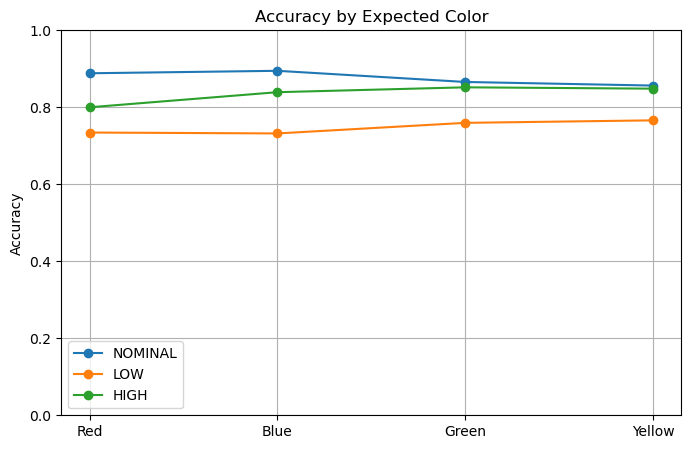

In [10]:
colors_order = ["Red", "Blue", "Green", "Yellow"]

fig, ax = plt.subplots(figsize=(8, 5))

for cond in ["NOMINAL", "LOW", "HIGH"]:
    subset = acc_by_color[acc_by_color["condition"] == cond].copy()
    subset["expected_response"] = pd.Categorical(subset["expected_response"], categories=colors_order, ordered=True)
    subset = subset.sort_values("expected_response")
    ax.plot(subset["expected_response"], subset["is_correct"], marker="o", label=cond)

ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Expected Color")
ax.grid(True)
ax.legend()
plt.show()

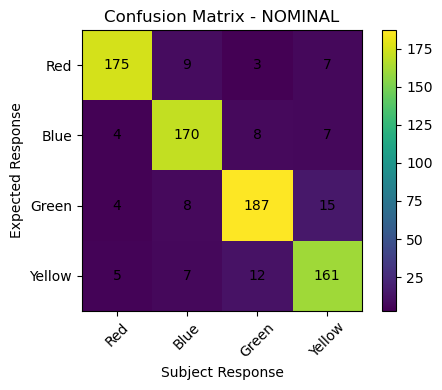

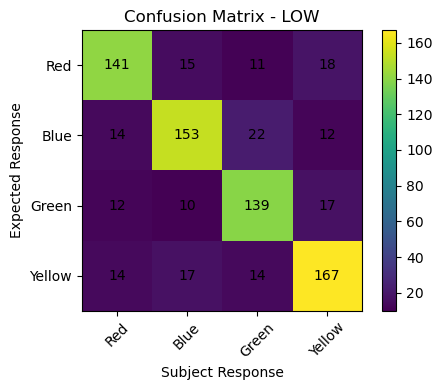

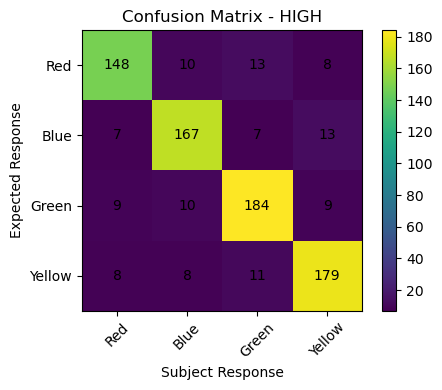

In [11]:
labels = ["Red", "Blue", "Green", "Yellow"]

for cond in ["NOMINAL", "LOW", "HIGH"]:
    subset = df_valid[
        (df_valid["condition"] == cond) &
        (df_valid["subject_response"] != "")
    ].copy()

    if len(subset) == 0:
        continue

    cm = confusion_matrix(
        subset["expected_response"],
        subset["subject_response"],
        labels=labels
    )

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {cond}")
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Subject Response")
    plt.ylabel("Expected Response")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

   subject condition  accuracy
2      ID1   NOMINAL  0.962963
5     ID10   NOMINAL  0.826087
6     ID11      HIGH  1.000000
10    ID12       LOW  1.000000
12    ID13      HIGH  1.000000
15    ID14      HIGH  1.000000
20    ID15   NOMINAL  0.964286
21    ID16      HIGH  1.000000
24    ID17      HIGH  1.000000
27    ID18      HIGH  1.000000
30    ID19      HIGH  0.965517
34     ID2       LOW  0.800000
37    ID20       LOW  1.000000
41    ID21   NOMINAL  1.000000
42    ID22      HIGH  1.000000
46    ID23       LOW  0.966667
48    ID24      HIGH  1.000000
51    ID25      HIGH  1.000000
56    ID26   NOMINAL  1.000000
57    ID27      HIGH  1.000000
62    ID28   NOMINAL  0.966667
64    ID29       LOW  0.965517
66     ID3      HIGH  0.916667
71    ID30   NOMINAL  1.000000
73     ID4       LOW  0.931034
77     ID5   NOMINAL  0.714286
80     ID6   NOMINAL  0.578947
81     ID7      HIGH  0.741935
86     ID8   NOMINAL  0.842105
88     ID9       LOW  0.826087


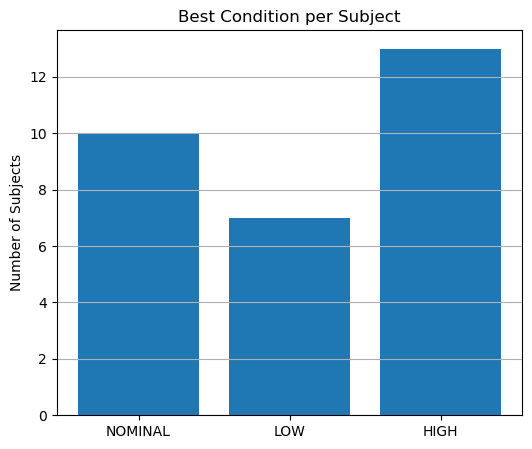

In [12]:
best_sc = summary_sc.loc[
    summary_sc.groupby("subject")["accuracy"].idxmax()
].copy()

print(best_sc[["subject", "condition", "accuracy"]])

best_counts = best_sc["condition"].value_counts().reindex(["NOMINAL", "LOW", "HIGH"], fill_value=0)

plt.figure(figsize=(6, 5))
plt.bar(best_counts.index, best_counts.values)
plt.ylabel("Number of Subjects")
plt.title("Best Condition per Subject")
plt.grid(axis="y")
plt.show()

## FRIEDMAN TEST



In [13]:
friedman_data = summary_sc.pivot(index="subject", columns="condition", values="accuracy")

friedman_data = friedman_data[["NOMINAL", "LOW", "HIGH"]].dropna()

print(friedman_data)

stat, p = friedmanchisquare(
    friedman_data["NOMINAL"],
    friedman_data["LOW"],
    friedman_data["HIGH"]
)

print("\nFriedman test on accuracy")
print("Statistic:", stat)
print("p-value:", p)

condition   NOMINAL       LOW      HIGH
subject                                
ID1        0.962963  0.846154  0.653846
ID10       0.826087  0.535714  0.653846
ID11       0.964286  1.000000  1.000000
ID12       0.964286  1.000000  0.966667
ID13       1.000000  1.000000  1.000000
ID14       1.000000  0.965517  1.000000
ID15       0.964286  0.266667  0.321429
ID16       0.535714  1.000000  1.000000
ID17       0.888889  0.571429  1.000000
ID18       1.000000  0.964286  1.000000
ID19       0.965517  0.857143  0.965517
ID2        0.695652  0.800000  0.714286
ID20       0.964286  1.000000  0.870968
ID21       1.000000  0.178571  0.966667
ID22       1.000000  1.000000  1.000000
ID23       0.933333  0.966667  0.958333
ID24       0.933333  0.928571  1.000000
ID25       1.000000  1.000000  1.000000
ID26       1.000000  0.129032  0.666667
ID27       0.933333  1.000000  1.000000
ID28       0.966667  0.466667  0.935484
ID29       0.823529  0.965517  0.666667
ID3        0.823529  0.793103  0.916667


## WILCOXON POST-HOC PAIRWISE


In [14]:
def safe_wilcoxon(x, y, label):
    data = pd.concat([x, y], axis=1).dropna()
    if len(data) < 2:
        print(f"{label}: not enough paired samples")
        return None
    stat, p = wilcoxon(data.iloc[:, 0], data.iloc[:, 1], zero_method="wilcox", alternative="two-sided")
    print(f"{label}: statistic={stat}, p={p}")
    return stat, p

print("\nPairwise Wilcoxon tests on subject-level accuracy")
safe_wilcoxon(friedman_data["NOMINAL"], friedman_data["LOW"], "NOMINAL vs LOW")
safe_wilcoxon(friedman_data["NOMINAL"], friedman_data["HIGH"], "NOMINAL vs HIGH")
safe_wilcoxon(friedman_data["LOW"], friedman_data["HIGH"], "LOW vs HIGH")


Pairwise Wilcoxon tests on subject-level accuracy
NOMINAL vs LOW: statistic=112.5, p=0.06597760187703769
NOMINAL vs HIGH: statistic=111.0, p=0.26513225086229597
LOW vs HIGH: statistic=85.0, p=0.06329083223334525


(85.0, 0.06329083223334525)

Delta LOW - NOMINAL
count    30.000000
mean     -0.139580
std       0.331574
min      -0.870968
25%      -0.314947
50%      -0.032454
75%       0.035714
max       0.464286
dtype: float64

Delta HIGH - NOMINAL
count    30.000000
mean     -0.046015
std       0.194042
min      -0.642857
25%      -0.140977
50%       0.000000
75%       0.033036
max       0.464286
dtype: float64


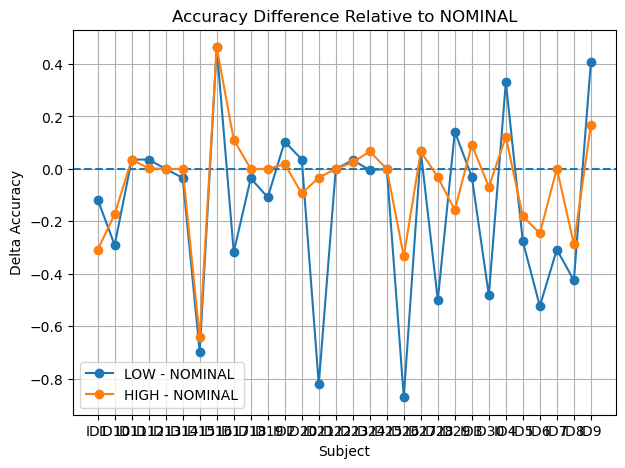

In [15]:
baseline = friedman_data["NOMINAL"]

delta_low = friedman_data["LOW"] - baseline
delta_high = friedman_data["HIGH"] - baseline

print("Delta LOW - NOMINAL")
print(delta_low.describe())

print("\nDelta HIGH - NOMINAL")
print(delta_high.describe())

plt.figure(figsize=(7, 5))
plt.axhline(0, linestyle="--")
plt.plot(delta_low.index, delta_low.values, marker="o", label="LOW - NOMINAL")
plt.plot(delta_high.index, delta_high.values, marker="o", label="HIGH - NOMINAL")
plt.ylabel("Delta Accuracy")
plt.xlabel("Subject")
plt.title("Accuracy Difference Relative to NOMINAL")
plt.grid(True)
plt.legend()
plt.show()

In [16]:
omit_data = summary_sc.pivot(index="subject", columns="condition", values="omission_rate")
omit_data = omit_data[["NOMINAL", "LOW", "HIGH"]].dropna()

if len(omit_data) >= 2:
    stat_o, p_o = friedmanchisquare(
        omit_data["NOMINAL"],
        omit_data["LOW"],
        omit_data["HIGH"]
    )
    print("\nFriedman test on omission rate")
    print("Statistic:", stat_o)
    print("p-value:", p_o)


Friedman test on omission rate
Statistic: 5.39285714285711
p-value: 0.06744596154539531


In [17]:
summary_sc.to_csv(base_path / "stats_subject_condition.csv", index=False)
summary_cond.to_csv(base_path / "stats_condition_summary.csv", index=False)
best_sc.to_csv(base_path / "stats_best_condition_per_subject.csv", index=False)
df_valid.to_csv(base_path / "stats_long_valid_trials.csv", index=False)

print("File statistici esportati.")

File statistici esportati.
